<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #0284c7; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Detección y Tratamiento de Valores Atípicos (Outliers) 🚨🎯
      </h1>
      <p style="margin: 6px 0 0 0; color: #0284c7; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Outlier Detection & Robustness
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #0369a1; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 01 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #0284c7; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/01_Deteccion_y_Tratamiento_de_Valores_Atipicos_Outliers.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Métodos Paramétricos y No Paramétricos de Detección 📐

| Método | Principio / Fórmula | ¿Supone Normalidad? | Alcance | Sensibilidad a los propios outliers extremos |
|---|---|---|---|---|
| **Regla de Tukey (IQR)** | Límites en $[Q_1 - 1.5 \cdot IQR,\; Q_3 + 1.5 \cdot IQR]$, con $IQR = Q_3 - Q_1$. | No. Se basa en cuantiles. | Univariado. | Baja: los cuantiles centrales apenas se mueven aunque el máximo se dispare. |
| **Puntaje Z (*Z-Score*)** | $\|Z\| = \left\|\dfrac{x - \mu}{\sigma}\right\| > 3$ | Sí, asume una distribución aproximadamente normal. | Univariado. | Alta: $\mu$ y, sobre todo, $\sigma$ se inflan con los propios outliers (**efecto de enmascaramiento**). |
| **Isolation Forest** | Algoritmo de ensamble basado en árboles que aísla cada punto mediante particiones aleatorias; los outliers se aíslan en menos divisiones (rutas más cortas). | No. No paramétrico. | Multivariado (usa varias columnas simultáneamente). | Baja/moderada: diseñado explícitamente para ser robusto ante anomalías. |

Los dos primeros métodos evalúan **una columna a la vez**; `IsolationForest` puede evaluar **varias columnas en conjunto**, lo que le permite detectar combinaciones anómalas de valores individualmente normales (ver Sección 5).

---
## 2. ¿Por Qué Importan los Valores Atípicos? ⚖️

Un outlier es una observación que se aleja sustancialmente del patrón general de los datos. Tratarlos bien requiere primero reconocer que **no todos los outliers son errores**:

* **Outliers como error de captura o de proceso:** dígitos de más, sensores mal calibrados, errores de digitación. En este dataset, una `edad` de **-3** o de **150** años no puede corresponder a una persona real: son errores que hay que corregir o tratar como faltantes, no información valiosa.
* **Outliers como señal genuina:** un `monto_prestamo` de $400 millones puede corresponder a un cliente corporativo o un crédito hipotecario real, no a un error. Eliminarlo sin más analizarlo puede borrar exactamente los casos de mayor interés para el negocio (fraude, clientes de alto valor, riesgo concentrado).

**Por qué distorsionan el análisis y el modelado:**
1. **Estadísticos no robustos:** la media, la varianza y la desviación estándar se desplazan fuertemente ante valores extremos (se retoma el ejemplo de `ingreso_mensual` del Cuaderno 00).
2. **Modelos basados en distancia:** KNN, K-Means o regresiones con penalización L2 dan un peso desproporcionado a observaciones lejanas.
3. **Supuestos distribucionales:** pruebas estadísticas y modelos que asumen normalidad pierden validez cuando la cola de la distribución está contaminada.

La disciplina correcta es: **detectar primero, decidir después** (¿es un error a corregir, un valor a acotar, o información legítima a conservar?), nunca eliminar por reflejo.

In [185]:
import os, urllib.request, urllib.parse, gzip, base64

_DATA_EMBEDDED = {
    "dataset_crudo_preprocesamiento.csv": "..."
}

def load_dataset(filename="dataset_crudo_preprocesamiento.csv", module_name="01 - Preprocesamiento de los Datos"):
    """
    Carga o descarga de forma segura el dataset para ejecución local o en Google Colab.
    Si no se encuentra localmente ni en GitHub, lo restaura automáticamente de forma exacta.
    """
    candidates = [
        os.path.join("data", filename),
        os.path.join(module_name, "data", filename),
        os.path.join("..", "data", filename),
        os.path.join("..", module_name, "data", filename),
        os.path.join("..", "..", "data", filename),
        os.path.join("Data Mining", module_name, "data", filename),
        os.path.join("..", "Data Mining", module_name, "data", filename),
        filename
    ]
    for path in candidates:
        if os.path.exists(path):
            return path

    os.makedirs("data", exist_ok=True)
    target_path = os.path.join("data", filename)
    folder_path = f"Data Mining/{module_name}"
    encoded_folder = urllib.parse.quote(folder_path)
    encoded_file = urllib.parse.quote(filename)

    urls = [
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/{encoded_folder}/data/{encoded_file}",
        f"https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/master/{encoded_folder}/data/{encoded_file}"
    ]

    print(f"[INFO] Intentando descargar '{filename}' desde el repositorio oficial...")
    for url in urls:
        try:
            with urllib.request.urlopen(url, timeout=2) as response:
                if response.status == 200:
                    with open(target_path, "wb") as out_f:
                        out_f.write(response.read())
                    print(f"[OK] Dataset '{filename}' descargado exitosamente.")
                    return target_path
        except Exception:
            continue

    if filename in _DATA_EMBEDDED:
        print(f"[INFO] Restaurando '{filename}' de forma autonoma...")
        data_bytes = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target_path, "wb") as out_f:
            out_f.write(data_bytes)
        print(f"[OK] Dataset '{filename}' preparado exitosamente en '{target_path}'.")
        return target_path

    raise FileNotFoundError(f"No se pudo encontrar ni generar el dataset '{filename}'.")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import os

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv(load_dataset("dataset_crudo_preprocesamiento.csv"))

columnas_numericas = ["edad", "ingreso_mensual", "score_credito", "tasa_interes", "monto_prestamo"]
print("Estadisticos descriptivos de las columnas numericas:")
display(df[columnas_numericas].describe())

Estadisticos descriptivos de las columnas numericas:


,edad,ingreso_mensual,score_credito,tasa_interes,monto_prestamo
count,"1,921.00","1,881.00","1,950.00","2,000.00","1,881.00"
mean,38.74,"4,553,973.86",650.21,2.87,"19,762,450.78"
std,14.71,"8,280,369.15",79.35,0.95,"39,110,494.80"
min,-3.00,"1,012.34",394.00,1.20,"4,348.32"
25%,30.00,"1,148,277.24",594.20,2.06,"4,793,625.67"
50%,38.00,"2,693,797.56",648.35,2.88,"11,452,492.16"
75%,46.00,"5,461,712.75",702.98,3.68,"23,154,768.80"
max,150.00,"95,000,000.00",850.00,4.50,"546,672,629.13"


---
## 3. Regla IQR de Tukey 📐

La regla de Tukey delimita un "rango aceptable" a partir de los cuartiles observados: cualquier valor por debajo de $Q_1 - 1.5 \cdot IQR$ o por encima de $Q_3 + 1.5 \cdot IQR$ se marca como atípico. Al depender solo de cuantiles, no exige que los datos sigan una distribución normal y es poco sensible a los propios valores extremos.

Se aplica primero sobre `edad`, la columna donde ya se sabe (Cuaderno 00) que existen valores imposibles.

In [186]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr, q1, q3, iqr


edad_valida = df["edad"].dropna()
lim_inf, lim_sup, q1, q3, iqr = limites_iqr(edad_valida)
print(f"edad -> Q1={q1:.1f} | Q3={q3:.1f} | IQR={iqr:.1f}")
print(f"edad -> limite inferior={lim_inf:.1f} | limite superior={lim_sup:.1f}")

atipicos_edad = edad_valida[(edad_valida < lim_inf) | (edad_valida > lim_sup)]
print(f"\nTotal de valores atipicos en edad (regla IQR): {len(atipicos_edad)} de {len(edad_valida)}")

imposibles = atipicos_edad[(atipicos_edad < 0) | (atipicos_edad > 100)]
extremos_plausibles = atipicos_edad[(atipicos_edad >= 0) & (atipicos_edad <= 100)]
print(f"  - Fisicamente imposibles (<0 o >100 anios): {len(imposibles)}")
print(f"  - Extremos pero fisicamente plausibles (entre {lim_inf:.0f} y 0, o entre 100 y {lim_sup:.0f}): {len(extremos_plausibles)}")

edad -> Q1=30.0 | Q3=46.0 | IQR=16.0
edad -> limite inferior=6.0 | limite superior=70.0

Total de valores atipicos en edad (regla IQR): 36 de 1921
  - Fisicamente imposibles (<0 o >100 anios): 26
  - Extremos pero fisicamente plausibles (entre 6 y 0, o entre 100 y 70): 10


In [187]:
monto_valido = df["monto_prestamo"].dropna()
lim_inf_m, lim_sup_m, q1_m, q3_m, iqr_m = limites_iqr(monto_valido)
print(f"monto_prestamo -> Q1={q1_m:,.2f} | Q3={q3_m:,.2f} | IQR={iqr_m:,.2f}")
print(f"monto_prestamo -> limite inferior={lim_inf_m:,.2f} | limite superior={lim_sup_m:,.2f}")
print("(el limite inferior es negativo, es decir, ningun monto real puede quedar por debajo: solo aplica el limite superior)")

atipicos_monto = monto_valido[(monto_valido < lim_inf_m) | (monto_valido > lim_sup_m)]
print(f"\nTotal de valores atipicos en monto_prestamo (regla IQR): {len(atipicos_monto)} de {len(monto_valido)} ({len(atipicos_monto) / len(monto_valido) * 100:.2f}%)")

monto_prestamo -> Q1=4,793,625.67 | Q3=23,154,768.80 | IQR=18,361,143.13
monto_prestamo -> limite inferior=-22,748,089.03 | limite superior=50,696,483.50
(el limite inferior es negativo, es decir, ningun monto real puede quedar por debajo: solo aplica el limite superior)

Total de valores atipicos en monto_prestamo (regla IQR): 130 de 1881 (6.91%)


<Axes: ylabel='edad'>

Text(0.5, 1.0, 'Boxplot: edad')

<Axes: ylabel='monto_prestamo'>

Text(0.5, 1.0, 'Boxplot: monto_prestamo')

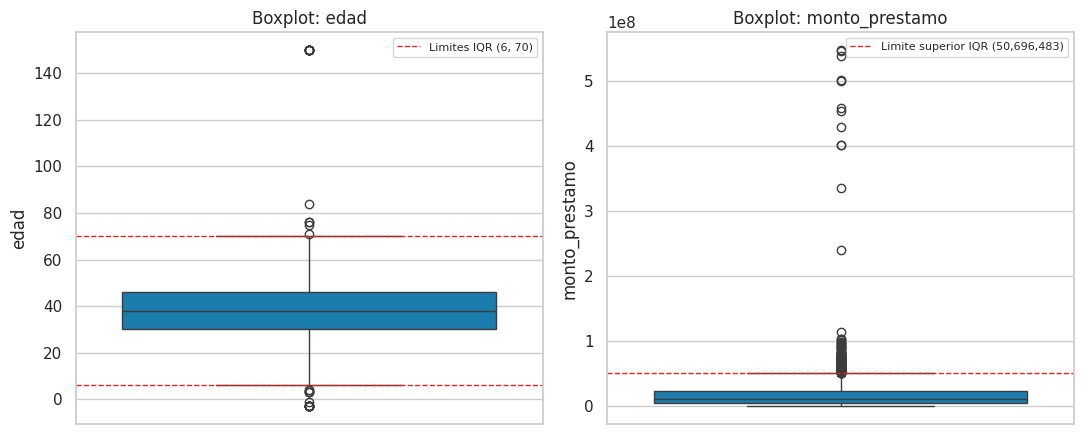

In [188]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(y=edad_valida, ax=axes[0], color="#0284c7")
axes[0].set_title("Boxplot: edad")
axes[0].axhline(lim_inf, color="#dc2626", linestyle="--", linewidth=1, label=f"Limites IQR ({lim_inf:.0f}, {lim_sup:.0f})")
axes[0].axhline(lim_sup, color="#dc2626", linestyle="--", linewidth=1)
axes[0].legend(fontsize=8)

sns.boxplot(y=monto_valido, ax=axes[1], color="#0284c7")
axes[1].set_title("Boxplot: monto_prestamo")
axes[1].axhline(lim_sup_m, color="#dc2626", linestyle="--", linewidth=1, label=f"Limite superior IQR ({lim_sup_m:,.0f})")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 4. Puntaje Z (*Z-Score*) 📐

El puntaje Z estandariza cada observación respecto a la media y la desviación estándar de su columna: $Z = \dfrac{x - \mu}{\sigma}$. Por convención, $|Z| > 3$ se considera atípico (bajo normalidad, deja fuera aproximadamente el 0.3% de las observaciones más extremas).

El método asume implícitamente una distribución aproximadamente normal y, sobre todo, **usa $\mu$ y $\sigma$ que se calculan a partir de los mismos datos que contienen los outliers** — si hay valores muy extremos, estos inflan la desviación estándar y "esconden" a otros outliers menos extremos dentro del rango de ±3σ. Este fenómeno se llama **efecto de enmascaramiento (*masking*)**.

In [189]:
def contar_atipicos_zscore(serie, umbral=3):
    z = (serie - serie.mean()) / serie.std()
    return (z.abs() > umbral).sum()


n_z_edad = contar_atipicos_zscore(edad_valida)
n_z_monto = contar_atipicos_zscore(monto_valido)

print("Comparacion IQR vs Z-Score (umbral |Z| > 3):")
print(f"  edad           -> IQR: {len(atipicos_edad)} atipicos | Z-Score: {n_z_edad} atipicos (de {len(edad_valida)})")
print(f"  monto_prestamo -> IQR: {len(atipicos_monto)} atipicos | Z-Score: {n_z_monto} atipicos (de {len(monto_valido)})")

Comparacion IQR vs Z-Score (umbral |Z| > 3):
  edad           -> IQR: 36 atipicos | Z-Score: 11 atipicos (de 1921)
  monto_prestamo -> IQR: 130 atipicos | Z-Score: 12 atipicos (de 1881)


**El efecto de enmascaramiento, con números reales:** en `monto_prestamo`, la regla IQR marca 130 observaciones (6.91%) como atípicas, mientras que el Z-Score solo detecta 12 (0.64%). La razón es mecánica: el valor máximo de la columna (más de 546 millones) es tan extremo que **infla la desviación estándar** usada para calcular cada Z, comprimiendo el resto de valores hacia el centro de la distribución estandarizada y haciendo que muchos outliers "reales" (según los cuantiles) queden por debajo del umbral $|Z|>3$. En `edad` ocurre lo mismo en menor escala (36 atípicos por IQR frente a 11 por Z-Score): los propios valores de -3 y 150 distorsionan la $\sigma$ que se usa para juzgarlos a ellos mismos y a sus vecinos.

Esta limitación motiva buscar un método que no dependa de un único par de estadísticos globales sensibles a los extremos — y que además pueda considerar varias variables a la vez, no solo una.

---
## 5. Detección Multivariada con `IsolationForest` 🌳

`IsolationForest` (Liu, Ting y Zhou, 2008) construye muchos árboles de decisión que particionan el espacio de variables mediante cortes aleatorios. La intuición central: **una observación anómala está "aislada"** respecto al resto de la nube de puntos, así que basta con **pocas particiones aleatorias** para separarla del resto — mientras que aislar una observación típica, rodeada de vecinos similares, requiere muchas más particiones. El algoritmo promedia la profundidad de aislamiento sobre todos los árboles del ensamble y la convierte en un puntaje de anomalía.

Su ventaja frente a IQR y Z-Score es que trabaja con **varias columnas simultáneamente**: puede detectar una *combinación* anómala de valores que, tomados uno por uno, parecen perfectamente normales (por ejemplo, una edad típica junto con una razón préstamo/ingreso desproporcionada).

In [190]:
sub_multivariado = df[["edad", "ingreso_mensual", "monto_prestamo"]].dropna().copy()

iso_forest = IsolationForest(contamination=0.02, random_state=42, n_estimators=200)
prediccion = iso_forest.fit_predict(sub_multivariado)
sub_multivariado["outlier"] = prediccion  # -1 = atipico, 1 = normal

n_outliers = (prediccion == -1).sum()
print(f"Observaciones completas evaluadas: {len(sub_multivariado)}")
print(f"Outliers multivariados detectados: {n_outliers} ({n_outliers / len(sub_multivariado) * 100:.2f}%)")

sub_multivariado["ratio_monto_ingreso"] = sub_multivariado["monto_prestamo"] / sub_multivariado["ingreso_mensual"]
outliers_edad_plausible = sub_multivariado[(sub_multivariado["outlier"] == -1) & (sub_multivariado["edad"].between(25, 55))]
print(f"\nDe esos outliers, {len(outliers_edad_plausible)} tienen una edad perfectamente plausible (25-55 anios):")
display(outliers_edad_plausible[["edad", "ingreso_mensual", "monto_prestamo", "ratio_monto_ingreso"]].head())

Observaciones completas evaluadas: 1806
Outliers multivariados detectados: 37 (2.05%)

De esos outliers, 21 tienen una edad perfectamente plausible (25-55 anios):


,edad,ingreso_mensual,monto_prestamo,ratio_monto_ingreso
0,44.00,"21,901,987.81","77,701,191.55",3.55
291,32.00,"95,000,000.00","401,493,935.50",4.23
318,42.00,"95,000,000.00","334,839,316.87",3.52
662,38.00,"95,000,000.00","400,969,873.11",4.22
710,41.00,"28,630,252.41","92,626,377.66",3.24


Text(0.5, 0, 'ingreso_mensual')

Text(0, 0.5, 'monto_prestamo')

Text(0.5, 1.0, 'IsolationForest sobre edad + ingreso_mensual + monto_prestamo\n(rojo = outlier multivariado)')

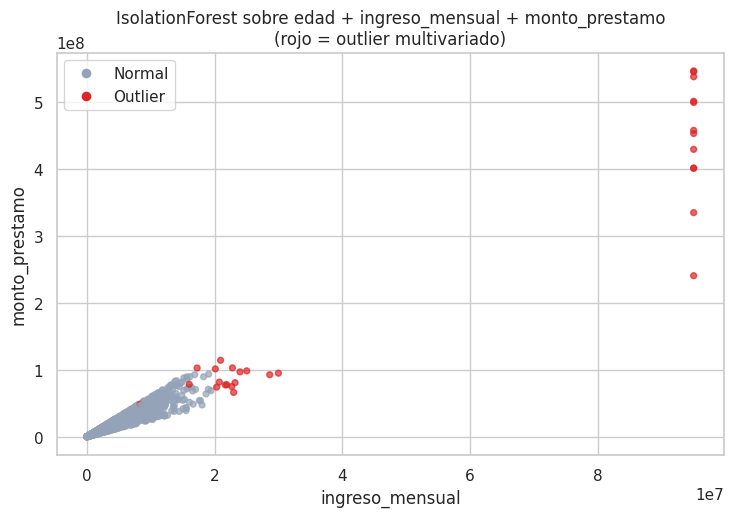

In [191]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colores = sub_multivariado["outlier"].map({1: "#94a3b8", -1: "#dc2626"})
ax.scatter(sub_multivariado["ingreso_mensual"], sub_multivariado["monto_prestamo"], c=colores, s=18, alpha=0.7)
ax.set_xlabel("ingreso_mensual")
ax.set_ylabel("monto_prestamo")
ax.set_title("IsolationForest sobre edad + ingreso_mensual + monto_prestamo\n(rojo = outlier multivariado)")
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#94a3b8", markersize=8, label="Normal"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#dc2626", markersize=8, label="Outlier"),
]
ax.legend(handles=handles)
plt.tight_layout()
plt.show()

**Lo que aporta el enfoque multivariado:** entre los 37 registros marcados por `IsolationForest`, 21 tienen una edad perfectamente plausible (entre 25 y 55 años) — ninguna regla univariada sobre `edad` los habría detectado. Lo que los hace anómalos es la **combinación** de sus variables: por ejemplo, un cliente con ingreso mensual de 21.9 millones que solicita un préstamo de 77.7 millones (una razón préstamo/ingreso ≈ 3.55, muy por encima de la razón típica del resto de la cartera). Ni `edad`, ni `ingreso_mensual`, ni `monto_prestamo` por separado se verían necesariamente atípicos en una regla IQR univariada aplicada a cada uno de forma aislada, pero juntos configuran un perfil de riesgo que un analista de crédito sí querría revisar.

---
## 6. Estrategias de Tratamiento tras la Detección 🛠️

Detectar un outlier es solo la primera mitad del trabajo. Qué hacer con él depende de si se interpreta como error o como señal genuina (Sección 2):

| Estrategia | Cuándo aplicarla | Efecto |
|---|---|---|
| **Corregir o tratar como faltante** | El valor es físicamente imposible (p. ej. `edad = -3` o `edad = 150`). | Convierte el error en `NaN` y lo remite a las técnicas de imputación del Cuaderno 00, en vez de dejarlo contaminar los estadísticos. |
| **Acotar / *Winsorizing*** (`clip` a un percentil, p. ej. [1, 99]) | El valor es plausible pero extremo, y se quiere conservar el registro sin que domine la escala. | Reduce la influencia del extremo sin eliminar la observación; cambia la varianza pero preserva el tamaño de muestra. |
| **Transformación (log, raíz cuadrada)** | Toda la columna tiene asimetría fuerte, no solo unos pocos puntos (`monto_prestamo`, `ingreso_mensual`). | Comprime la escala de la cola larga sin descartar información; útil antes de modelos sensibles a la escala. |
| **Eliminar el registro** | El outlier es un error irrecuperable y no se puede corregir ni imputar razonablemente, y son pocos casos. | Reduce el tamaño de muestra; debe documentarse y justificarse siempre. |
| **Conservar y marcar (*flag*)** | El outlier es información legítima de negocio (fraude, cliente VIP, riesgo concentrado). | Añade una columna binaria de alerta y dejar el valor intacto para que el modelo o el analista lo considere explícitamente. |

A modo de ejemplo, se aplica *winsorizing* sobre `monto_prestamo` acotando al percentil [1, 99], una alternativa más suave que eliminar directamente los 130 registros marcados por IQR.

In [192]:
p1, p99 = monto_valido.quantile([0.01, 0.99])
monto_acotado = monto_valido.clip(lower=p1, upper=p99)

print(f"Percentiles usados como limites: p1={p1:,.2f} | p99={p99:,.2f}")
print(f"\nAntes de acotar  -> media={monto_valido.mean():,.2f} | std={monto_valido.std():,.2f} | maximo={monto_valido.max():,.2f}")
print(f"Despues de acotar -> media={monto_acotado.mean():,.2f} | std={monto_acotado.std():,.2f} | maximo={monto_acotado.max():,.2f}")
print(f"\nRegistros acotados por arriba (> p99): {(monto_valido > p99).sum()}")
print(f"Registros acotados por abajo (< p1): {(monto_valido < p1).sum()}")

Percentiles usados como limites: p1=175,052.01 | p99=95,312,207.22

Antes de acotar  -> media=19,762,450.78 | std=39,110,494.80 | maximo=546,672,629.13
Despues de acotar -> media=17,503,586.64 | std=18,686,747.36 | maximo=95,312,207.22

Registros acotados por arriba (> p99): 19
Registros acotados por abajo (< p1): 19


---
## 7. Tabla de Decisión: ¿Qué Método Usar? ⚖️

| Situación | Método recomendado | Motivo |
|---|---|---|
| Una sola variable, se necesita un criterio simple e interpretable para reportar a negocio | **IQR de Tukey** | No asume normalidad, es fácil de explicar ("fuera del rango típico ± 1.5 IQR") y es robusto ante los propios extremos. |
| Una sola variable, se sabe que sigue una distribución aproximadamente normal | **Z-Score** | Cuando la normalidad es razonable, el umbral $|Z|>3$ tiene una interpretación probabilística directa; evitar si hay outliers muy extremos que inflen $\sigma$ (efecto de enmascaramiento, Sección 4). |
| Varias variables numéricas, se sospechan combinaciones anómalas que ningún criterio univariado captura | **IsolationForest** | Detecta anomalías conjuntas (Sección 5); no requiere supuestos distribucionales; escala razonablemente bien con más columnas. |
| Se requiere máxima interpretabilidad para auditoría o cumplimiento normativo | **IQR de Tukey** | El criterio se puede explicar con una fórmula de una línea; `IsolationForest` es más difícil de justificar ante un regulador o un comité de crédito. |
| Se prioriza detectar fraude o combinaciones de riesgo sobre variables correlacionadas | **IsolationForest** | Rendimiento muy superior cuando la anomalía vive en la interacción entre variables, no en ninguna marginal. |
| Dataset con outliers ya conocidos como errores de captura (edades imposibles, códigos centinela) | **IQR o reglas de dominio explícitas**, tratados como faltantes | El objetivo no es "detectar" sino corregir un error de calidad de datos conocido; ver Sección 6. |

---
## 8. Ejercicio Práctico Guiado: IQR sobre `score_credito` 📝

**Contexto:** `score_credito` es una variable numérica sin valores nulos inyectados por fuera de los 50 nulos ya auditados en el Cuaderno 00, con un rango teórico típico de puntaje crediticio (300-850 puntos aproximadamente).

**Tu misión:**
1. Calcula $Q_1$, $Q_3$ y el $IQR$ de `score_credito` (usa `.dropna()` para descartar los nulos).
2. Calcula los límites inferior y superior de la regla de Tukey.
3. Filtra las filas cuyo `score_credito` cae fuera de esos límites.
4. Reporta cuántas filas fueron marcadas y muestra sus valores de `score_credito` ordenados.

In [193]:
### TU CÓDIGO AQUÍ ###
# 1. Calcula Q1, Q3 e IQR de score_credito
score_valido = None
q1_score, q3_score = None, None
iqr_score = None

# 2. Calcula los límites de Tukey
limite_inf_score = None
limite_sup_score = None

# 3. Filtra las filas fuera de esos límites
atipicos_score = None

# 4. Reporta resultados
print(f"Límites IQR para score_credito: [{limite_inf_score}, {limite_sup_score}]")
print(f"Filas marcadas como atípicas: {len(atipicos_score) if atipicos_score is not None else 0}")
if atipicos_score is not None:
    print(sorted(atipicos_score.tolist() if hasattr(atipicos_score, 'tolist') else list(atipicos_score)))


Límites IQR para score_credito: [None, None]
Filas marcadas como atípicas: 0


<details>
<summary>💡 Ver solución propuesta</summary>

```python
# 1. Calcula Q1, Q3 e IQR de score_credito
score_valido = df["score_credito"].dropna()
q1_score, q3_score = score_valido.quantile([0.25, 0.75])
iqr_score = q3_score - q1_score

# 2. Calcula los limites de Tukey
limite_inf_score = q1_score - 1.5 * iqr_score
limite_sup_score = q3_score + 1.5 * iqr_score

# 3. Filtra las filas fuera de esos limites
atipicos_score = score_valido[(score_valido < limite_inf_score) | (score_valido > limite_sup_score)]

# 4. Reporta resultados
print(f"Limites IQR para score_credito: [{limite_inf_score:.2f}, {limite_sup_score:.2f}]")
print(f"Filas marcadas como atipicas: {len(atipicos_score)}")
print(sorted(atipicos_score.tolist()))
```

Con los datos de este módulo, el resultado esperado son **5 registros marcados**, todos por debajo del límite inferior (≈ 431 puntos) — ninguno supera el límite superior porque el máximo observado (850) está dentro del rango típico de un puntaje crediticio. Los 5 valores atípicos se concentran entre 394 y 424 puntos: clientes de riesgo crediticio inusualmente bajo que merecerían revisión manual antes de decidir si son errores de captura o solicitantes genuinamente de alto riesgo.

</details>

---
## 9. Resumen Ejecutivo del Cuaderno 01 📌

1. **Un outlier no es automáticamente un error:** puede ser un dato imposible que corregir (`edad = -3` o `150`) o una señal de negocio legítima (`monto_prestamo` alto de un cliente corporativo); la decisión de tratamiento depende de esa distinción, no solo de la detección.
2. **La regla IQR de Tukey confirmó los errores ya sospechados:** de los 36 valores de `edad` marcados como atípicos, 26 son físicamente imposibles (fuera de [0, 100] años) — validando con un criterio estadístico formal lo que la auditoría de calidad ya intuía en el Cuaderno 00.
3. **El Z-Score sufre un fuerte efecto de enmascaramiento en columnas con colas muy largas:** en `monto_prestamo`, IQR detectó 130 atípicos (6.91%) frente a solo 12 (0.64%) del Z-Score, porque los propios valores extremos inflan la desviación estándar usada para calcularlo.
4. **`IsolationForest` detecta anomalías que ningún método univariado puede ver:** 21 de los 37 outliers multivariados detectados sobre `edad`, `ingreso_mensual` y `monto_prestamo` tenían una edad perfectamente normal (25-55 años); lo anómalo era la combinación de sus variables (razón préstamo/ingreso desproporcionada).
5. **Detectar y tratar son pasos distintos:** corregir, acotar (*winsorizing*), transformar, eliminar o simplemente marcar son estrategias válidas según el contexto (Sección 6) — no existe una única respuesta correcta para "qué hacer" con un outlier ya detectado.
6. **Con esto se cierra el Módulo 01 de Preprocesamiento:** valores faltantes (Cuaderno 00) y valores atípicos (este cuaderno) son, junto con la codificación de variables categóricas y el escalado, los pilares de cualquier pipeline de minería de datos antes de pasar a la fase de modelado.

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Minería de Datos | Preprocesamiento de Datos</i>
  </p>
</div>